<a href="https://colab.research.google.com/github/k-gyo/MLDL/blob/main/%ED%98%BC%EC%9E%90%20%EA%B3%B5%EB%B6%80%ED%95%98%EB%8A%94%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%2B%20%EB%94%A5%EB%9F%AC%EB%8B%9D/Chapter08_%EC%9D%B4%EB%AF%B8%EC%A7%80%EB%A5%BC_%EC%9C%84%ED%95%9C_%EC%9D%B8%EA%B3%B5_%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **케라스 합성곱 층**

In [1]:
from tensorflow import keras
keras.layers.Conv2D(10, kernel_size=(3, 3), activation='relu')
# Conv2D: 합성곱
# 첫 번째 매개변수: 필터의 개수
# kernel size: 매개변수는 필터에 사용할 커널의 크기 -> 하이퍼파라미터지만 보통 (3, 3)이나 (5.5) 크기가 권장됨

<Conv2D name=conv2d, built=False>

# **패딩과 스트라이드**

In [2]:
keras.layers.Conv2D(10, kernel_size=(3, 3), activation='relu', padding='same')

<Conv2D name=conv2d_1, built=False>

In [3]:
keras.layers.Conv2D(10, kernel_size=(3, 3), activation='relu', padding='same', strides=1)

<Conv2D name=conv2d_2, built=False>

# **풀링**

In [4]:
keras.layers.MaxPooling2D(2)

<MaxPooling2D name=max_pooling2d, built=True>

In [5]:
keras.layers.MaxPooling2D(2, strides=2, padding='valid')

<MaxPooling2D name=max_pooling2d_1, built=True>

# **패션 MNIST 데이터 불러오기**

In [6]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **합성곱 신경망 만들기**

### 첫 번째 합성곱-풀링 층

In [7]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                              padding='same', input_shape=(28, 28, 1)))
#  합성곱 층은 32개의 필터를 사용, 커널의 크기는 (3, 3), 렐루 활성화 함수와 세임 패딩을 사용

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(keras.layers.MaxPooling2D(2))

# 합성곱 층에서 32개의 필터를 사용했기 때문에 이 특성 맵의 깊이는 32
# 최대 풀링을 통과한 특성 맵의 크기는(14, 14, 32)가 될 것

### 두 번째 합성곱-풀링 층

In [9]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

#  64개의 필터를 사용했으므로 최종적으로 만들어지는 특성 맵의 크기는 (7, 7, 64)가 될 것

In [10]:
# Flatten 클래스 다음에 Dense 은닉층, 마지막으로 Dense 출력층의 순서대로 구성

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**결과 해석**

- 첫 번째 합성곱 층:
  - 32개의 필터
  - 크기: (3, 3)
  - 깊이: 1
  - 필터마다 하나의 절편이 있음
  > 따라서 총 3 × 3 × 1 × 32 + 32 = 320개의 파라미터가 있음

- 두 번째 합성곱 층:
  - 64개의 필터
  - 크기: (3.3)
  - 깊이: 32
  - 필터마다 하나의 절편이 있음
  > 따라서 총 3 × 3 × 32 × 64 + 64 = 18,496개의 파라미터가 있음

  - Flatten 클래스
    - (7, 7, 64) 크기의 특성 맵을 1차원 배열로 펼치면 (3136,) 크기의 배열이 됨
    - 이를 100개의 뉴런과 완전히 연결해야 하므로 은닉층의 모델 파라미터 개수는 3.136 × 100 + 100 = 313,700개

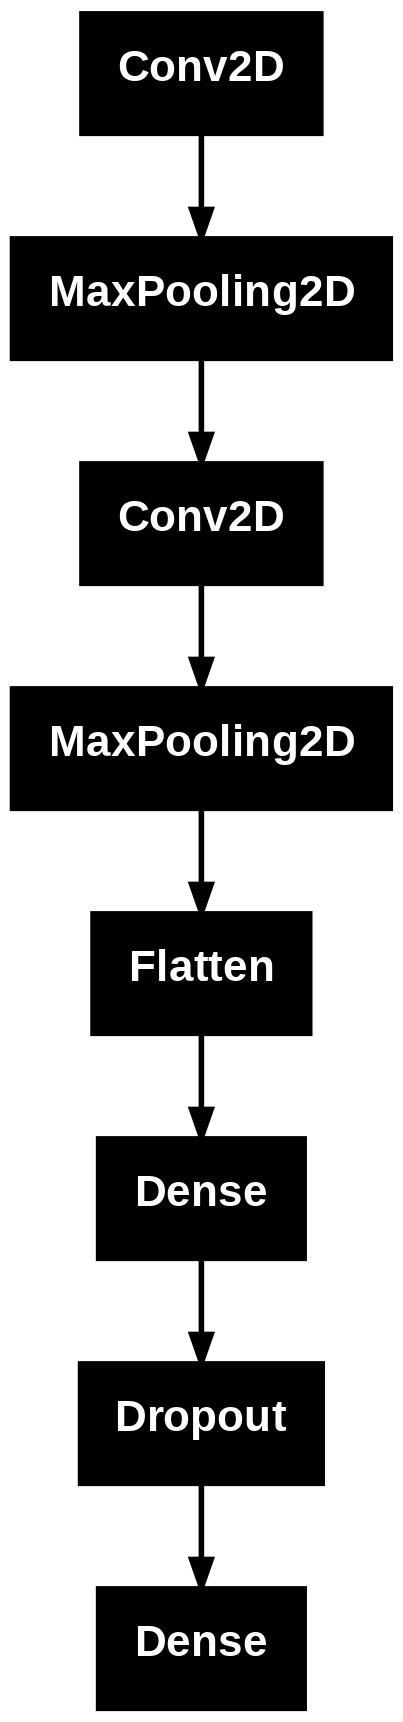

In [13]:
keras.utils.plot_model(model)

# 층의 구성을 그림으로 표현

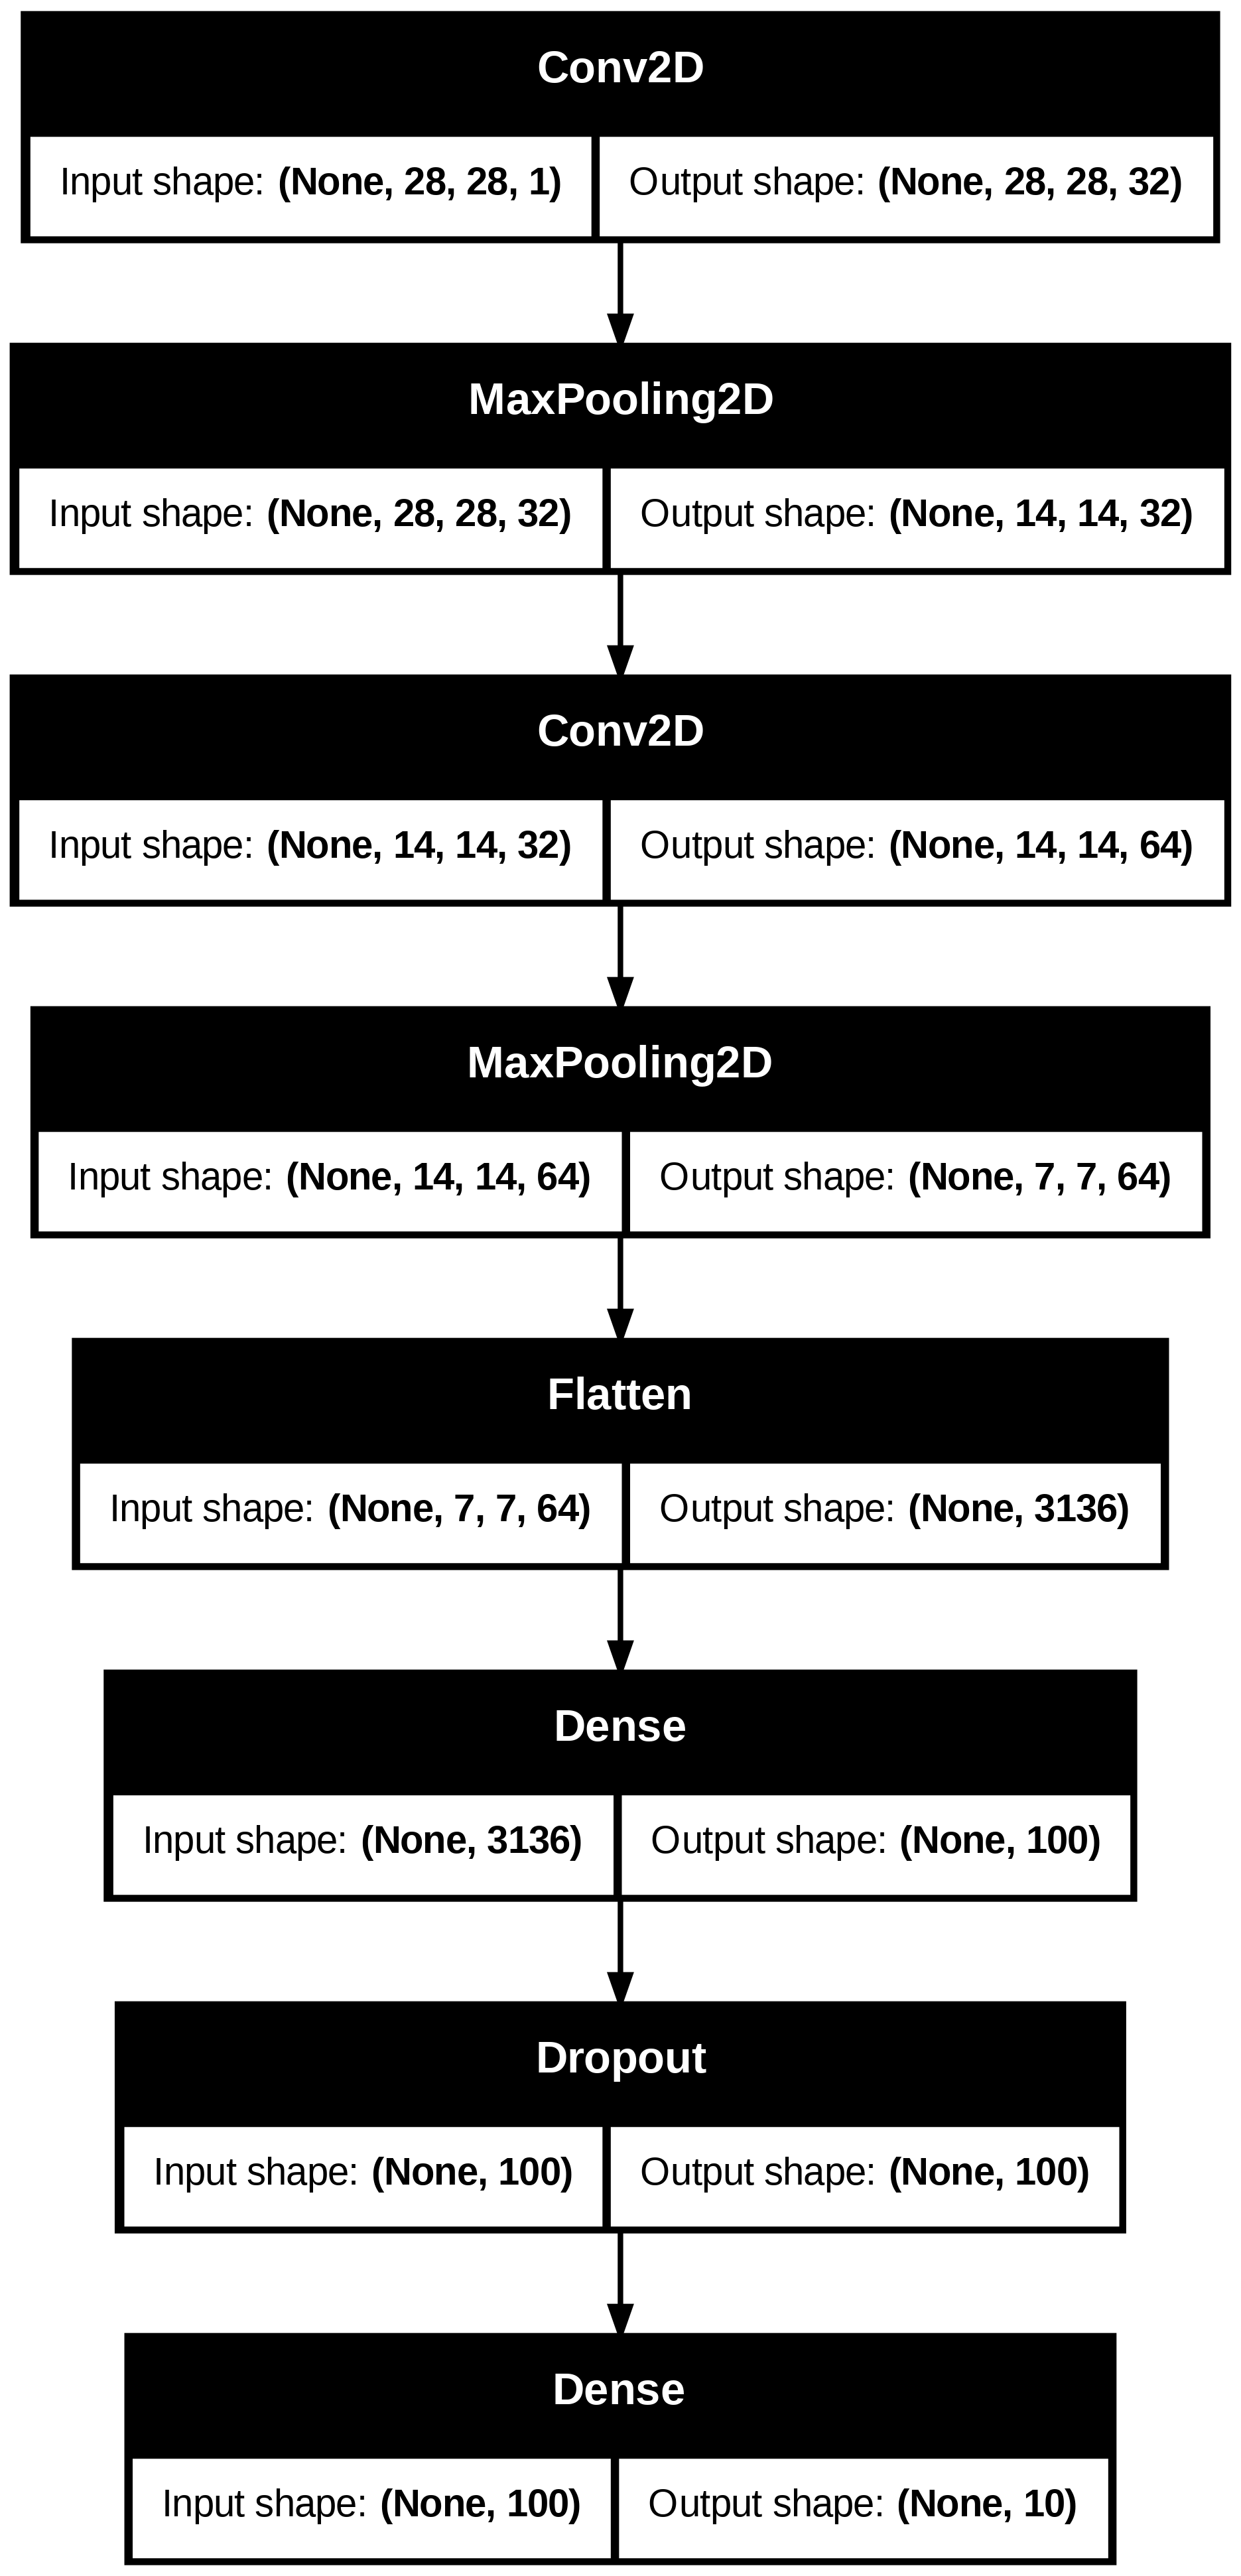

In [15]:
keras.utils.plot_model(model, show_shapes=True,
                       to_file='cnn-architechture.png', dpi=300)
# show_shapes 매개변수를 True로 설정하면 이 그림에 입력과 출력의 크기를 표시
# to file 매개변수에 파일 이름을 지정하면 출력한 이미지를 파일로 저장
# dpi 매개변수로 해상도를 지정

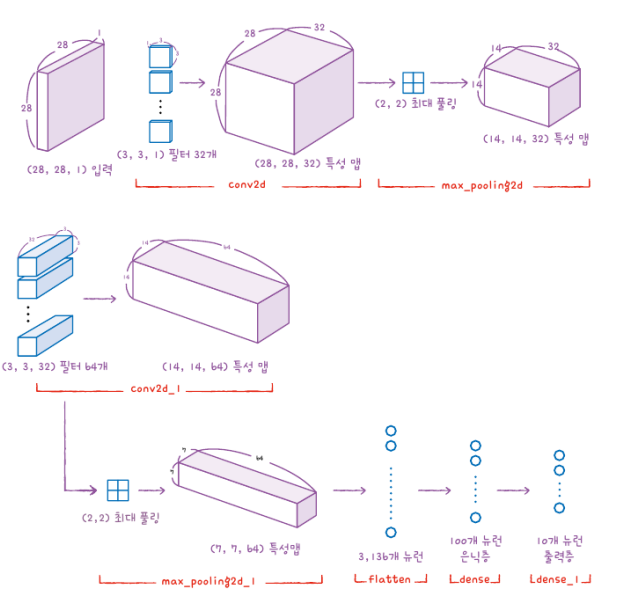

# **모델 컴파일과 훈련**

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7377 - loss: 0.7253

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.7377 - loss: 0.7252 - val_accuracy: 0.8772 - val_loss: 0.3306
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8744 - loss: 0.3568

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 47ms/step - accuracy: 0.8744 - loss: 0.3568 - val_accuracy: 0.8969 - val_loss: 0.2761
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8920 - loss: 0.2951

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 43ms/step - accuracy: 0.8920 - loss: 0.2951 - val_accuracy: 0.9028 - val_loss: 0.2546
Epoch 4/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9024 - loss: 0.2625

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.9024 - loss: 0.2625 - val_accuracy: 0.9087 - val_loss: 0.2416
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9124 - loss: 0.2342

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 89s 48ms/step - accuracy: 0.9204 - loss: 0.2172 - val_accuracy: 0.9158 - val_loss: 0.2252
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9248 - loss: 0.1996

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.9248 - loss: 0.1996 - val_accuracy: 0.9115 - val_loss: 0.2421
Epoch 8/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9307 - loss: 0.1847

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 42ms/step - accuracy: 0.9307 - loss: 0.1847 - val_accuracy: 0.9238 - val_loss: 0.2102
Epoch 9/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9355 - loss: 0.1696

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.9355 - loss: 0.1697 - val_accuracy: 0.9233 - val_loss: 0.2157
Epoch 10/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9399 - loss: 0.1587

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9399 - loss: 0.1587 - val_accuracy: 0.9262 - val_loss: 0.2220


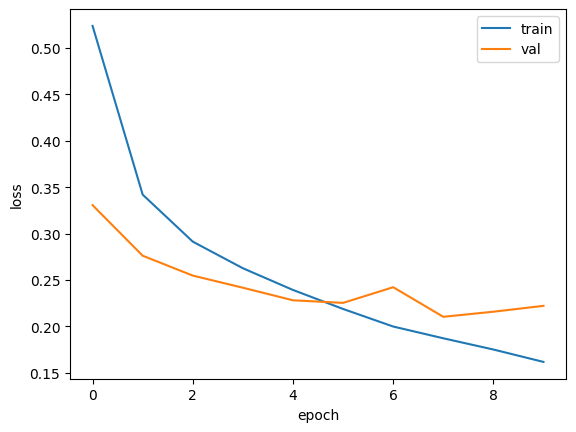

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [19]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9246 - loss: 0.2072


[0.21021299064159393, 0.9238333106040955]

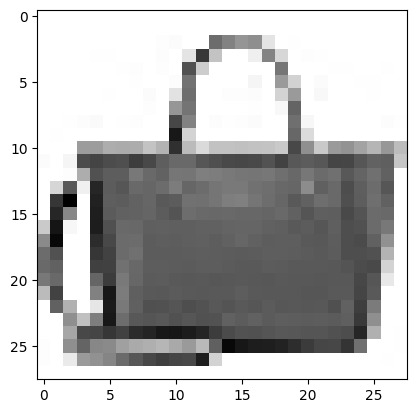

In [20]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [21]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[3.3905057e-20 3.1235984e-28 9.8326838e-25 5.0924292e-21 1.4222043e-21
  1.3886980e-20 3.7882303e-20 9.3295341e-22 1.0000000e+00 3.0395365e-24]]


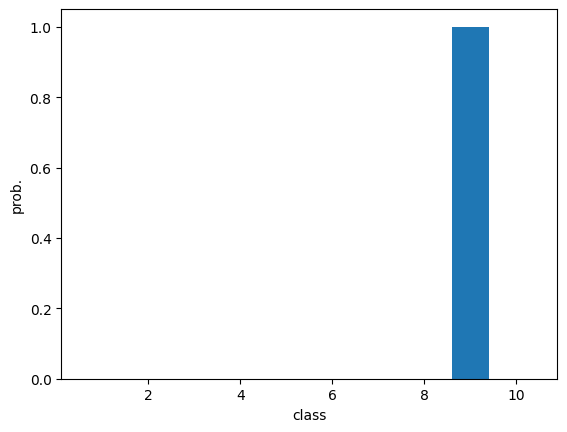

In [22]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [23]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈',
           '가방', '앵클 부츠']

In [24]:
import numpy as np
print(classes[np.argmax(preds)])

가방


In [25]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [26]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9168 - loss: 0.2496


[0.2414998710155487, 0.9157000184059143]